## Punganur Tomato Price Intelligence System
### Using Agmarknet Mandi Data



In [2]:
import os
os.getcwd()


'C:\\Users\\DELL\\Tomato_Project'

In [3]:
import os
os.listdir()



['.ipynb_checkpoints',
 'clean_punganur_tomato_prices(2022-2026).csv',
 'clean_punganur_tomato_prices.csv',
 'Daily Price Report-25-12-2021 to 24-12-2022 for Andhra Pradesh.csv',
 'Daily Price Report-25-12-2022 to 24-12-2023 for Andhra Pradesh.csv',
 'Daily Price Report-25-12-2023 to 24-12-2024 for Andhra Pradesh.csv',
 'Daily Price Report-25-12-2024 to 25-12-2025 for Andhra Pradesh.csv',
 'dataset(2022-2025).csv',
 'monthly_tomato_decision_table.csv',
 'tomato_price_analysis.ipynb',
 'tomato_price_forecast_2026.csv',
 'tomato_pro.pbix']

## Load Raw Mandi Data


In [4]:
import pandas as pd

# Read the four CSV files
df1 = pd.read_csv("Daily Price Report-25-12-2024 to 25-12-2025 for Andhra Pradesh.csv")
df2 = pd.read_csv("Daily Price Report-25-12-2023 to 24-12-2024 for Andhra Pradesh.csv")
df3 = pd.read_csv("Daily Price Report-25-12-2022 to 24-12-2023 for Andhra Pradesh.csv")
df4 = pd.read_csv("Daily Price Report-25-12-2021 to 24-12-2022 for Andhra Pradesh.csv")

main_dataset_df = pd.concat([df1, df2, df3, df4], ignore_index=True)

main_dataset_df.to_csv("dataset(2022-2025).csv", index=False)

print(main_dataset_df.shape)

(1151, 12)


In [5]:
import pandas as pd
df_raw = pd.read_csv("dataset(2022-2025).csv")

df = df_raw.copy()
df.head()

,State,District,Market,Commodity Group,Commodity,Variety,Grade,Min Price,Max Price,Modal Price,Price Unit,Price Date
0,Andhra Pradesh,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,"2,000.00","4,000.00","3,000.00",Rs./Quintal,24-12-2025
1,Andhra Pradesh,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,"2,400.00","4,400.00","3,400.00",Rs./Quintal,23-12-2025
2,Andhra Pradesh,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,"2,840.00","4,340.00","3,340.00",Rs./Quintal,22-12-2025
3,Andhra Pradesh,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,"2,800.00","4,800.00","3,800.00",Rs./Quintal,21-12-2025
4,Andhra Pradesh,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,"3,740.00","4,670.00","4,270.00",Rs./Quintal,20-12-2025


## Convert Price Columns to Numeric


In [6]:
price_cols = ["Min Price", "Max Price", "Modal Price"]

for col in price_cols:
    df[col] = df[col].str.replace(",", "").astype(float)
df.head()

,State,District,Market,Commodity Group,Commodity,Variety,Grade,Min Price,Max Price,Modal Price,Price Unit,Price Date
0,Andhra Pradesh,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,2000.0,4000.0,3000.0,Rs./Quintal,24-12-2025
1,Andhra Pradesh,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,2400.0,4400.0,3400.0,Rs./Quintal,23-12-2025
2,Andhra Pradesh,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,2840.0,4340.0,3340.0,Rs./Quintal,22-12-2025
3,Andhra Pradesh,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,2800.0,4800.0,3800.0,Rs./Quintal,21-12-2025
4,Andhra Pradesh,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,3740.0,4670.0,4270.0,Rs./Quintal,20-12-2025


## Convert Price Date to Datetime


In [7]:
df["Price Date"] = pd.to_datetime(df["Price Date"], format="%d-%m-%Y")
df.head()

,State,District,Market,Commodity Group,Commodity,Variety,Grade,Min Price,Max Price,Modal Price,Price Unit,Price Date
0,Andhra Pradesh,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,2000.0,4000.0,3000.0,Rs./Quintal,2025-12-24
1,Andhra Pradesh,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,2400.0,4400.0,3400.0,Rs./Quintal,2025-12-23
2,Andhra Pradesh,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,2840.0,4340.0,3340.0,Rs./Quintal,2025-12-22
3,Andhra Pradesh,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,2800.0,4800.0,3800.0,Rs./Quintal,2025-12-21
4,Andhra Pradesh,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,3740.0,4670.0,4270.0,Rs./Quintal,2025-12-20


## Sort by Date

In [8]:
df = df.sort_values("Price Date")
df.head()

,State,District,Market,Commodity Group,Commodity,Variety,Grade,Min Price,Max Price,Modal Price,Price Unit,Price Date
1150,Andhra Pradesh,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,670.0,4270.0,2470.0,Rs./Quintal,2022-01-01
1149,Andhra Pradesh,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,670.0,4270.0,2470.0,Rs./Quintal,2022-01-02
1148,Andhra Pradesh,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,670.0,2800.0,1740.0,Rs./Quintal,2022-01-03
1147,Andhra Pradesh,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,670.0,2670.0,1670.0,Rs./Quintal,2022-01-05
1146,Andhra Pradesh,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,670.0,2670.0,1670.0,Rs./Quintal,2022-01-06


# Phase 2 – Market Analysis & Insights
Understanding how tomato prices behave over time in Punganur


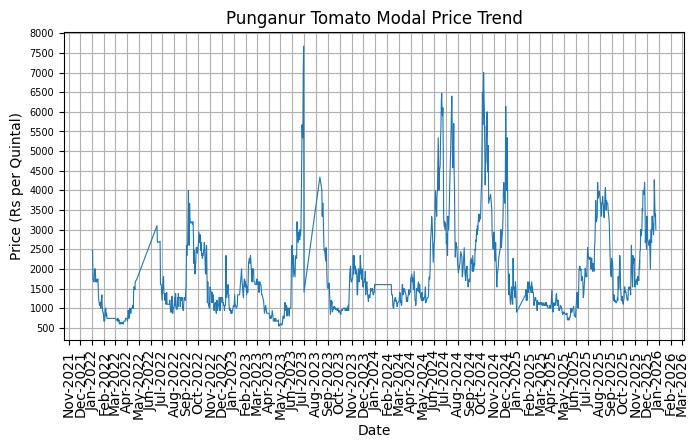

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

plt.figure(figsize=(8,4))
plt.plot(df["Price Date"], df["Modal Price"], linewidth=0.8)

plt.title("Punganur Tomato Modal Price Trend")
plt.xlabel("Date")
plt.ylabel("Price (Rs per Quintal)")

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))

plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(500))
plt.grid(True)

plt.xticks(rotation=90)
plt.yticks(fontsize=7)

plt.show()



## Monthly Price Trend
This section analyzes how average tomato prices change month by month to identify seasonal profit patterns.


In [10]:
df["Month"] = df["Price Date"].dt.to_period("M")
monthly_avg = df.groupby("Month")["Modal Price"].mean()
monthly_avg

Month
2022-01    1507.407407
2022-02     767.142857
2022-03     663.600000
2022-04    1069.523810
2022-06    2063.333333
2022-07    1174.230769
2022-08    1194.444444
2022-09    2727.200000
2022-10    2157.586207
2022-11    1160.384615
2022-12    1144.333333
2023-01    1370.000000
2023-02    1822.500000
2023-03    1296.166667
2023-04     726.538462
2023-05     991.290323
2023-06    3365.652174
2023-07    1410.000000
2023-08    2880.000000
2023-09    1082.800000
2023-10    1118.666667
2023-11    1875.000000
2023-12    1473.225806
2024-02    1256.500000
2024-03    1338.518519
2024-04    1478.518519
2024-05    1856.296296
2024-06    4343.103448
2024-07    3786.785714
2024-08    1980.400000
2024-09    2613.928571
2024-10    4683.333333
2024-11    2729.583333
2024-12    2230.344828
2025-01    1410.000000
2025-02    1296.666667
2025-03    1093.000000
2025-04    1052.142857
2025-05     842.000000
2025-06    1648.769231
2025-07    2745.000000
2025-08    3419.285714
2025-09    1480.714286
2025-

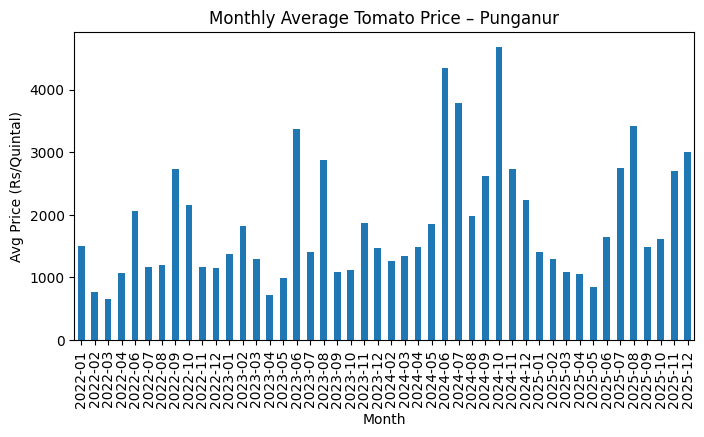

In [11]:
monthly_avg.plot(kind="bar", figsize=(8,4))
plt.title("Monthly Average Tomato Price – Punganur")
plt.xlabel("Month")
plt.ylabel("Avg Price (Rs/Quintal)")
plt.xticks(rotation=90)
plt.show()


## Price Volatility (Risk Analysis)
This section measures how unstable tomato prices are each month using standard deviation.
Higher volatility means higher risk.


In [15]:
monthly_volatility = df.groupby("Month")["Modal Price"].std()
monthly_volatility


Month
2022-01     469.521791
2022-02      86.610788
2022-03      49.655480
2022-04     319.491411
2022-06     714.387850
2022-07     237.860011
2022-08     156.753931
2022-09     521.588280
2022-10     625.931621
2022-11     180.985762
2022-12     286.196018
2023-01     272.843322
2023-02     299.001963
2023-03     340.117073
2023-04     103.264410
2023-05     453.921740
2023-06    1660.612773
2023-07            NaN
2023-08     829.995366
2023-09     227.660566
2023-10     353.433731
2023-11     253.006065
2023-12     169.673944
2024-02     204.663395
2024-03     140.101713
2024-04     225.945938
2024-05     733.543288
2024-06    1150.823008
2024-07    1305.470126
2024-08     259.269487
2024-09     558.989427
2024-10    1328.813353
2024-11     704.528699
2024-12    1474.324259
2025-01     146.590890
2025-02     201.627990
2025-03      92.704573
2025-04     134.063477
2025-05      90.378514
2025-06     374.131133
2025-07     744.727144
2025-08     557.925580
2025-09     401.966726
2025-

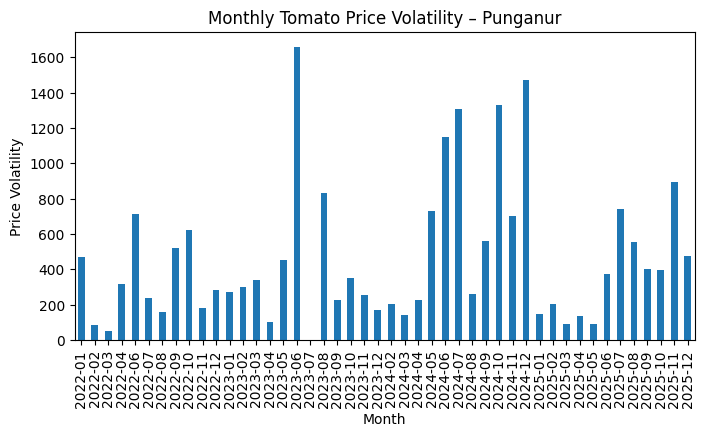

In [14]:
monthly_volatility.plot(kind="bar", figsize=(8,4))
plt.title("Monthly Tomato Price Volatility – Punganur")
plt.xlabel("Month")
plt.ylabel("Price Volatility")
plt.xticks(rotation=90)
plt.show()


## Profit vs Risk Decision Table
This table combines monthly average price (profit) and volatility (risk) to classify each month into
safe, risky, or high-profit market conditions.


In [16]:
monthly_avg = df.groupby("Month")["Modal Price"].mean()
monthly_volatility = df.groupby("Month")["Modal Price"].std()

decision_table = pd.DataFrame({
    "Avg Price": monthly_avg,
    "Volatility": monthly_volatility
})

decision_table


,Avg Price,Volatility
Month,,
2022-01,1507.407407,469.521791
2022-02,767.142857,86.610788
2022-03,663.600000,49.655480
2022-04,1069.523810,319.491411
2022-06,2063.333333,714.387850
2022-07,1174.230769,237.860011
2022-08,1194.444444,156.753931
2022-09,2727.200000,521.588280
2022-10,2157.586207,625.931621


In [67]:
def classify(row):
    if row["Avg Price"] > 2500 and row["Volatility"] < 400:
        return "Best (High profit, low risk)"
    elif row["Avg Price"] > 2500 and row["Volatility"] >= 400:
        return "High profit, High risk"
    elif row["Avg Price"] <= 2500 and row["Volatility"] < 200:
        return "Low profit, Safe"
    else:
        return "Moderate"

decision_table["Market Type"] = decision_table.apply(classify, axis=1)
decision_table


,Avg Price,Volatility,Market Type
Month,,,
2022-01,1507.407407,469.521791,Moderate
2022-02,767.142857,86.610788,"Low profit, Safe"
2022-03,663.600000,49.655480,"Low profit, Safe"
2022-04,1069.523810,319.491411,Moderate
2022-06,2063.333333,714.387850,Moderate
2022-07,1174.230769,237.860011,Moderate
2022-08,1194.444444,156.753931,"Low profit, Safe"
2022-09,2727.200000,521.588280,"High profit, High risk"
2022-10,2157.586207,625.931621,Moderate


## Risk vs Profit Market Map
Each point represents one month.
This chart helps identify which months offer the best balance between profit and risk.


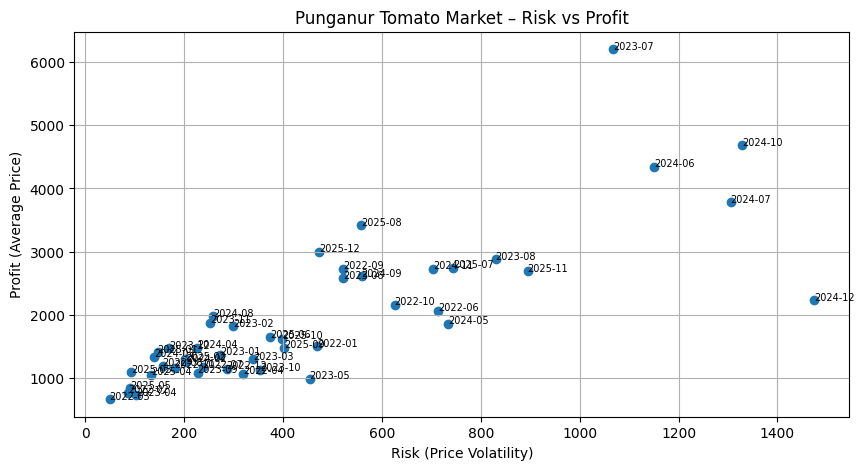

In [70]:
plt.figure(figsize=(10,5))
plt.scatter(decision_table["Volatility"], decision_table["Avg Price"])

plt.xlabel("Risk (Price Volatility)")
plt.ylabel("Profit (Average Price)")
plt.title("Punganur Tomato Market – Risk vs Profit")

for month in decision_table.index:
    plt.text(decision_table.loc[month, "Volatility"],
             decision_table.loc[month, "Avg Price"],
             str(month), fontsize=7)

plt.grid(True)
plt.show()


## Export Tables to Power BI 

In [18]:

df.to_csv("clean_punganur_tomato_prices.csv", index=False)

df.head()


,State,District,Market,Commodity Group,Commodity,Variety,Grade,Min Price,Max Price,Modal Price,Price Unit,Price Date
1150,Andhra Pradesh,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,670.0,4270.0,2470.0,Rs./Quintal,2022-01-01
1149,Andhra Pradesh,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,670.0,4270.0,2470.0,Rs./Quintal,2022-01-02
1148,Andhra Pradesh,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,670.0,2800.0,1740.0,Rs./Quintal,2022-01-03
1147,Andhra Pradesh,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,670.0,2670.0,1670.0,Rs./Quintal,2022-01-05
1146,Andhra Pradesh,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,670.0,2670.0,1670.0,Rs./Quintal,2022-01-06


In [72]:
decision_table.to_csv("monthly_tomato_decision_table.csv")
decision_table.head()

,Avg Price,Volatility,Market Type
Month,,,
2022-01,1507.407407,469.521791,Moderate
2022-02,767.142857,86.610788,"Low profit, Safe"
2022-03,663.600000,49.655480,"Low profit, Safe"
2022-04,1069.523810,319.491411,Moderate
2022-06,2063.333333,714.387850,Moderate


## Monthly Time Series for Forecasting

In [73]:
import pandas as pd

df = pd.read_csv("clean_punganur_tomato_prices.csv")

df["Price Date"] = pd.to_datetime(df["Price Date"])

df["Month"] = df["Price Date"].dt.to_period("M")

monthly = df.groupby("Month")["Modal Price"].mean().reset_index()

monthly["Month"] = monthly["Month"].astype(str)

monthly


,Month,Modal Price
0,2022-01,1507.407407
1,2022-02,767.142857
2,2022-03,663.600000
3,2022-04,1069.523810
4,2022-06,2063.333333
5,2022-07,1174.230769
6,2022-08,1194.444444
7,2022-09,2727.200000
8,2022-10,2157.586207
9,2022-11,1160.384615


## Train Prophet Forecast Model

In [74]:
pip install prophet


Note: you may need to restart the kernel to use updated packages.


In [75]:
from prophet import Prophet

forecast_df = monthly.rename(columns={
    "Month": "ds",
    "Modal Price": "y"
})

forecast_df


Importing plotly failed. Interactive plots will not work.


,ds,y
0,2022-01,1507.407407
1,2022-02,767.142857
2,2022-03,663.600000
3,2022-04,1069.523810
4,2022-06,2063.333333
5,2022-07,1174.230769
6,2022-08,1194.444444
7,2022-09,2727.200000
8,2022-10,2157.586207
9,2022-11,1160.384615


In [76]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(forecast_df)


03:00:54 - cmdstanpy - INFO - Chain [1] start processing
03:00:55 - cmdstanpy - INFO - Chain [1] done processing


## Generate Future Predictions

In [77]:
future = model.make_future_dataframe(periods=6, freq='M')
future 

C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\prophet\forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds
0,2022-01-01
1,2022-02-01
2,2022-03-01
3,2022-04-01
4,2022-06-01
5,2022-07-01
6,2022-08-01
7,2022-09-01
8,2022-10-01
9,2022-11-01


In [82]:
forecast = model.predict(future)
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(6)


,ds,yhat,yhat_lower,yhat_upper
46,2025-12-31,3787.605633,2844.790763,4769.163214
47,2026-01-31,2250.183493,1287.862371,3240.801994
48,2026-02-28,1456.160704,515.244664,2415.987243
49,2026-03-31,557.826593,-431.476354,1552.041471
50,2026-04-30,466.932468,-436.338140,1479.938592
51,2026-05-31,1489.738801,530.689981,2527.761195


## Forecast Tomato Price Trend(Historical + Future)

<Figure size 800x400 with 0 Axes>

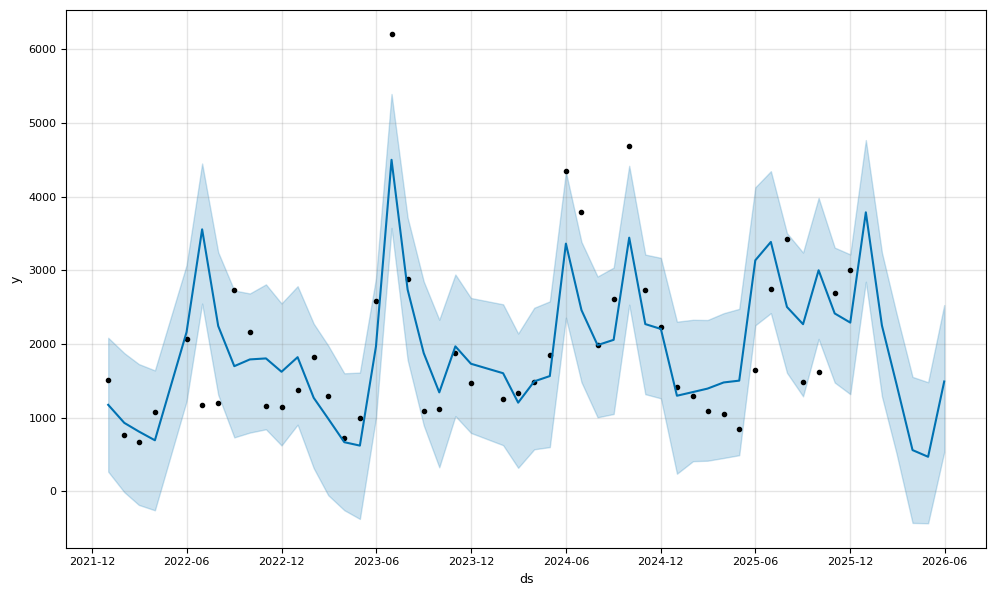

In [83]:

import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8
})

plt.figure(figsize=(8,4))
model.plot(forecast)
plt.show()


## Extract Forecast Results

In [84]:
forecast_table = forecast[['ds','yhat','yhat_lower','yhat_upper']]
forecast_table.tail(6)

forecast_table = forecast_table.rename(columns={
    "ds": "Month",
    "yhat": "Expected Price",
    "yhat_lower": "Worst Case Price",
    "yhat_upper": "Best Case Price"
})

forecast_table


,Month,Expected Price,Worst Case Price,Best Case Price
0,2022-01-01,1172.818288,264.491762,2083.653897
1,2022-02-01,927.686922,-13.695738,1875.267922
2,2022-03-01,810.450456,-186.941769,1726.639668
3,2022-04-01,691.089916,-259.860574,1640.343839
4,2022-06-01,2160.345399,1222.807980,3071.222517
5,2022-07-01,3556.222129,2547.938933,4450.705002
6,2022-08-01,2243.415053,1309.183762,3245.419729
7,2022-09-01,1697.916060,730.286960,2725.974591
8,2022-10-01,1789.545356,795.497755,2685.608460
9,2022-11-01,1803.149891,840.569547,2808.875420


## Expected Market Scenario

In [85]:
def classify_market(row):
    if row['Expected Price'] > 2800:
        return "High Profit, High Risk"
    elif row['Expected Price'] > 1800:
        return "Moderate"
    else:
        return "Low Profit, Safe"

forecast_table['Market_Type'] = forecast_table.apply(classify_market, axis=1)
forecast_table


,Month,Expected Price,Worst Case Price,Best Case Price,Market_Type
0,2022-01-01,1172.818288,264.491762,2083.653897,"Low Profit, Safe"
1,2022-02-01,927.686922,-13.695738,1875.267922,"Low Profit, Safe"
2,2022-03-01,810.450456,-186.941769,1726.639668,"Low Profit, Safe"
3,2022-04-01,691.089916,-259.860574,1640.343839,"Low Profit, Safe"
4,2022-06-01,2160.345399,1222.807980,3071.222517,Moderate
5,2022-07-01,3556.222129,2547.938933,4450.705002,"High Profit, High Risk"
6,2022-08-01,2243.415053,1309.183762,3245.419729,Moderate
7,2022-09-01,1697.916060,730.286960,2725.974591,"Low Profit, Safe"
8,2022-10-01,1789.545356,795.497755,2685.608460,"Low Profit, Safe"
9,2022-11-01,1803.149891,840.569547,2808.875420,Moderate


## Export Data to Power BI

In [86]:
forecast_table.to_csv("tomato_price_forecast_2026.csv", index=False)
